#Analisis de tuberculosis


**Cargar los datos**

In [1]:
# Paquetes para manipular datos.
import pandas as pd
import numpy as np

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)


In [2]:
# Paquetes para conectarse a drive.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# CVS population
pop = pd.read_csv("/content/drive/MyDrive/A/population.csv")
pop.head()

,country,year,population
0,Afghanistan,1995,17586073
1,Afghanistan,1996,18415307
2,Afghanistan,1997,19021226
3,Afghanistan,1998,19496836
4,Afghanistan,1999,19987071


In [4]:
# CVS who
who = pd.read_csv("/content/drive/MyDrive/A/who.csv")
who.head()

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
0,Afghanistan,AF,AFG,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,AF,AFG,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,AF,AFG,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,AF,AFG,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,AF,AFG,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


La tuberculosis (TB) es una enfermedad infecciosa causada por la bacteria Mycobacterium tuberculosis. Afecta principalmente a los pulmones, pero también puede afectar otras partes del cuerpo como los riñones, la columna vertebral y el cerebro. Se transmite de persona a persona a través del aire cuando una persona con TB pulmonar tose, estornuda o habla. Los síntomas comunes incluyen tos persistente (a veces con sangre), dolor en el pecho, debilidad o fatiga, pérdida de peso, fiebre y sudores nocturnos.

Los métodos de diagnóstico de la tuberculosis incluyen:

Prueba cutánea de tuberculina (PPD): Mide la respuesta inmune del cuerpo a la bacteria de la TB.
Análisis de sangre (IGRAs): Pruebas de liberación de interferón gamma que detectan la presencia de la bacteria de la TB.
Radiografía de tórax: Busca signos de daño pulmonar causado por la TB.
Análisis de esputo: Se examina una muestra de esputo (moco que se expulsa al toser) para detectar la presencia de la bacteria de la TB. Esto puede incluir un frotis para bacilos ácido-alcohol resistentes (BAAR) y un cultivo.
Biopsia: En algunos casos, se puede tomar una pequeña muestra de tejido de un órgano afectado para su análisis.
Pruebas moleculares rápidas: Detectan el material genético de la bacteria de la TB y pueden identificar la resistencia a ciertos medicamentos.

#Limpieza y manipulación de datos

**Explorar los valores nulos/faltantes/NA**

In [5]:
# Cuantos NA hay por columna.
who.isna().sum()

,0
country,0
iso2,34
iso3,0
year,0
new_sp_m014,4067
new_sp_m1524,4031
new_sp_m2534,4034
new_sp_m3544,4021
new_sp_m4554,4017
new_sp_m5564,4022


In [6]:
#Explora los valores faltantes en la columna iso2
who[who.iso2.isna()]

,country,iso2,iso3,year,new_sp_m014,new_sp_m1524,new_sp_m2534,new_sp_m3544,new_sp_m4554,new_sp_m5564,new_sp_m65,new_sp_f014,new_sp_f1524,new_sp_f2534,new_sp_f3544,new_sp_f4554,new_sp_f5564,new_sp_f65,new_sn_m014,new_sn_m1524,new_sn_m2534,new_sn_m3544,new_sn_m4554,new_sn_m5564,new_sn_m65,new_sn_f014,new_sn_f1524,new_sn_f2534,new_sn_f3544,new_sn_f4554,new_sn_f5564,new_sn_f65,new_ep_m014,new_ep_m1524,new_ep_m2534,new_ep_m3544,new_ep_m4554,new_ep_m5564,new_ep_m65,new_ep_f014,new_ep_f1524,new_ep_f2534,new_ep_f3544,new_ep_f4554,new_ep_f5564,new_ep_f65,newrel_m014,newrel_m1524,newrel_m2534,newrel_m3544,newrel_m4554,newrel_m5564,newrel_m65,newrel_f014,newrel_f1524,newrel_f2534,newrel_f3544,newrel_f4554,newrel_f5564,newrel_f65
4369,Namibia,NaN,NAM,1980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4370,Namibia,NaN,NAM,1981,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4371,Namibia,NaN,NAM,1982,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4372,Namibia,NaN,NAM,1983,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4373,Namibia,NaN,NAM,1984,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4374,Namibia,NaN,NAM,1985,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4375,Namibia,NaN,NAM,1986,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4376,Namibia,NaN,NAM,1987,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4377,Namibia,NaN,NAM,1988,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4378,Namibia,NaN,NAM,1989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#Los valores NA se deben a que iso2 de Nambia es "NA" y pandas lo toma como valor faltante.
who.loc[who.country == "Namibia", "iso2"] = "NA"

In [8]:
# Las demas columnas de casos con valores faltantes van a tener un valor default de 0.
who.fillna(0, inplace=True)

In [9]:
# Cuantos valores faltantes hay por columna en la tabla pop?
pop.isna().sum()

,0
country,0
year,0
population,0


In [10]:
# Como convertir columnas en filas utilizando pandas? con la funcion melt().
who2 = who.melt(id_vars=["country", "iso2", "iso3", "year"])
who2.head(10)


,country,iso2,iso3,year,variable,value
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0


In [11]:
# Crear columna que contenga el genero (masculino, femenino)
#Crear una función de python que contenga reglas
def asignar_genero(valor):
  if "m" in valor:
    return "Masculino"
  else:
    return "Femenino"


In [12]:
who2["genero"] = who2["variable"].apply(asignar_genero)
who2.head(10)

,country,iso2,iso3,year,variable,value,genero
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,Masculino
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,Masculino
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,Masculino
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,Masculino
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,Masculino
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0,Masculino
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0,Masculino
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0,Masculino
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0,Masculino
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0,Masculino


In [13]:
# the method of diagnosis (rel = relapse, sn = negative pulmonary smear, sp = positive pulmonary smear, ep = extrapulmonary)
def asignar_metodo(valor):
  if "rel" in valor:
    return "relapse"
  elif "sn" in valor:
    return "negative pulmonary smear"
  elif "sp" in valor:
    return "positive pulmonary smear"
  elif "ep" in valor:
    return "extrapulmonary"
  else:
    return "to define"

In [14]:
who2["metodo"] = who2["variable"].apply(asignar_metodo)
who2.head(10)

,country,iso2,iso3,year,variable,value,genero,metodo
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,Masculino,positive pulmonary smear
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,Masculino,positive pulmonary smear
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,Masculino,positive pulmonary smear
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,Masculino,positive pulmonary smear
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,Masculino,positive pulmonary smear
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0,Masculino,positive pulmonary smear
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0,Masculino,positive pulmonary smear
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0,Masculino,positive pulmonary smear
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0,Masculino,positive pulmonary smear
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0,Masculino,positive pulmonary smear


In [15]:
# age group (014 = 0-14 yrs of age, 1524 = 15-24, 2534 = 25-34, 3544 = 35-44 years of age, 4554 = 45-54, 5564 = 55-64, 65 = 65 years or older).
def asignar_grupoedad(valor):
  if "014" in valor:
    return "0-14"
  elif "1524" in valor:
    return "15-24"
  elif "2534" in valor:
    return "25-34"
  elif "3544" in valor:
    return "35-44"
  elif "4554" in valor:
    return "45-54"
  elif "5564" in valor:
    return "55-64"
  else:
    return "65+"

In [16]:
who2["propiedad"] = who2["variable"].apply(asignar_grupoedad)
who2.head(10)

,country,iso2,iso3,year,variable,value,genero,metodo,propiedad
0,Afghanistan,AF,AFG,1980,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
1,Afghanistan,AF,AFG,1981,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
2,Afghanistan,AF,AFG,1982,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
3,Afghanistan,AF,AFG,1983,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
4,Afghanistan,AF,AFG,1984,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
5,Afghanistan,AF,AFG,1985,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
6,Afghanistan,AF,AFG,1986,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
7,Afghanistan,AF,AFG,1987,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
8,Afghanistan,AF,AFG,1988,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14
9,Afghanistan,AF,AFG,1989,new_sp_m014,0.0,Masculino,positive pulmonary smear,0-14


In [17]:
#Remover la columna variable.
who2.drop(columns=["variable"], inplace=True)

In [18]:
# Renombrar columna value a casos
who2.rename(columns={"value":"cases"}, inplace=True)
who2.head(10)

,country,iso2,iso3,year,cases,genero,metodo,propiedad
0,Afghanistan,AF,AFG,1980,0.0,Masculino,positive pulmonary smear,0-14
1,Afghanistan,AF,AFG,1981,0.0,Masculino,positive pulmonary smear,0-14
2,Afghanistan,AF,AFG,1982,0.0,Masculino,positive pulmonary smear,0-14
3,Afghanistan,AF,AFG,1983,0.0,Masculino,positive pulmonary smear,0-14
4,Afghanistan,AF,AFG,1984,0.0,Masculino,positive pulmonary smear,0-14
5,Afghanistan,AF,AFG,1985,0.0,Masculino,positive pulmonary smear,0-14
6,Afghanistan,AF,AFG,1986,0.0,Masculino,positive pulmonary smear,0-14
7,Afghanistan,AF,AFG,1987,0.0,Masculino,positive pulmonary smear,0-14
8,Afghanistan,AF,AFG,1988,0.0,Masculino,positive pulmonary smear,0-14
9,Afghanistan,AF,AFG,1989,0.0,Masculino,positive pulmonary smear,0-14


In [19]:
# Traer el dato de la poblacion total
df = pd.merge(who2, pop, on=["country", "year"], how="inner")
df.head(10)

,country,iso2,iso3,year,cases,genero,metodo,propiedad,population
0,Afghanistan,AF,AFG,1995,0.0,Masculino,positive pulmonary smear,0-14,17586073
1,Afghanistan,AF,AFG,1996,0.0,Masculino,positive pulmonary smear,0-14,18415307
2,Afghanistan,AF,AFG,1997,0.0,Masculino,positive pulmonary smear,0-14,19021226
3,Afghanistan,AF,AFG,1998,30.0,Masculino,positive pulmonary smear,0-14,19496836
4,Afghanistan,AF,AFG,1999,8.0,Masculino,positive pulmonary smear,0-14,19987071
5,Afghanistan,AF,AFG,2000,52.0,Masculino,positive pulmonary smear,0-14,20595360
6,Afghanistan,AF,AFG,2001,129.0,Masculino,positive pulmonary smear,0-14,21347782
7,Afghanistan,AF,AFG,2002,90.0,Masculino,positive pulmonary smear,0-14,22202806
8,Afghanistan,AF,AFG,2003,127.0,Masculino,positive pulmonary smear,0-14,23116142
9,Afghanistan,AF,AFG,2004,139.0,Masculino,positive pulmonary smear,0-14,24018682


In [20]:
# Como guardar la tabla "df" como un archivo csv
df.to_csv("tuberculosis.csv") # se guarda en la carpeta de la sesion
df.to_csv("/content/drive/MyDrive/A/tuberculosis.csv") # se guarda en el drive

# Exploración de datos con Python.

In [21]:
# Como agrupar y resumir datos con Python
# Por genero
por_genero = df.groupby("genero", as_index = False)["cases"].sum()
por_genero["porcentaje"] = 100 * por_genero["cases"] / por_genero["cases"].sum()
por_genero.head()

,genero,cases,porcentaje
0,Femenino,15818663.0,36.640815
1,Masculino,27353584.0,63.359185


In [23]:
# Como agrupar y resumir datos con Python
# Por metodo
por_metodo = df.groupby("metodo", as_index=False)["cases"].sum()
por_metodo["porcentaje"] = 100 * por_metodo["cases"] / por_metodo["cases"].sum()
por_metodo.head()

,metodo,cases,porcentaje
0,extrapulmonary,1986179.0,4.600592
1,negative pulmonary smear,6279526.0,14.545284
2,positive pulmonary smear,31701213.0,73.429611
3,relapse,3205329.0,7.424513


In [26]:
# Como agrupar y resumir datos con Python
# Por edad
por_grupoedad = df.groupby("propiedad", as_index=False)["cases"].sum()
por_grupoedad["porcentaje"] = 100 * por_grupoedad["cases"] / por_grupoedad["cases"].sum()
por_grupoedad.head()

,propiedad,cases,porcentaje
0,0-14,1702349.0,3.943156
1,15-24,7594407.0,17.590947
2,25-34,9562886.0,22.150540
3,35-44,8720495.0,20.199308
4,45-54,6475709.0,14.999703


In [27]:
# La cantidad de Paises afectados, Año de inicio y el año de finalizacion
print(f"Cantidad de Paises: {df.country.nunique()}") # nunique es lo mismo que un count(distinct)
print(f"El año de inicio es: {df.year.min()}")
print(f"El año de finalizacion es: {df.year.max()}")

Cantidad de Paises: 217
El año de inicio es: 1995
El año de finalizacion es: 2013


Tasa de incidencia (por cada 100 mil habitantes) = 100,000 * casos nuevo / poblacion

In [28]:
# Nueva tabla para calcular la incidencia
country_year = df.groupby(["country", "year"], as_index=False).agg({"cases":"sum", "population":"max"})
country_year["tasa_incidencia"] = 100_000 * country_year["cases"] / country_year["population"]
country_year.head(10)

,country,year,cases,population,tasa_incidencia
0,Afghanistan,1995,0.0,17586073,0.000000
1,Afghanistan,1996,0.0,18415307,0.000000
2,Afghanistan,1997,128.0,19021226,0.672932
3,Afghanistan,1998,1778.0,19496836,9.119428
4,Afghanistan,1999,745.0,19987071,3.727410
5,Afghanistan,2000,2666.0,20595360,12.944663
6,Afghanistan,2001,4639.0,21347782,21.730595
7,Afghanistan,2002,6509.0,22202806,29.316114
8,Afghanistan,2003,6528.0,23116142,28.240006
9,Afghanistan,2004,8245.0,24018682,34.327446


In [29]:
# Nueva tablara para calcular la tasa de incidencia POR AÑO
by_year = country_year.groupby("year", as_index=False).agg(
    {"cases":"sum", "population": "sum"}
)
by_year["tasa_incidencia"] = 100_000 * by_year["cases"] / by_year["population"]
by_year

,year,cases,population,tasa_incidencia
0,1995,505717.0,5703289735,8.867110
1,1996,628318.0,5781863871,10.867049
2,1997,724163.0,5858936095,12.359974
3,1998,830998.0,5934972576,14.001716
4,1999,986176.0,6010587100,16.407316
5,2000,1148463.0,6086267209,18.869743
6,2001,1227501.0,6162187587,19.919890
7,2002,1512296.0,6239282896,24.238298
8,2003,1849403.0,6315958969,29.281428
9,2004,2172788.0,6393225245,33.985788


In [30]:
import matplotlib.pyplot as plt # base de visualizacion en Python
import seaborn as sns # visualizaciones mas sencillas hechas sobre Matplotlib
import plotly.express as px # visualizaciones interactivas


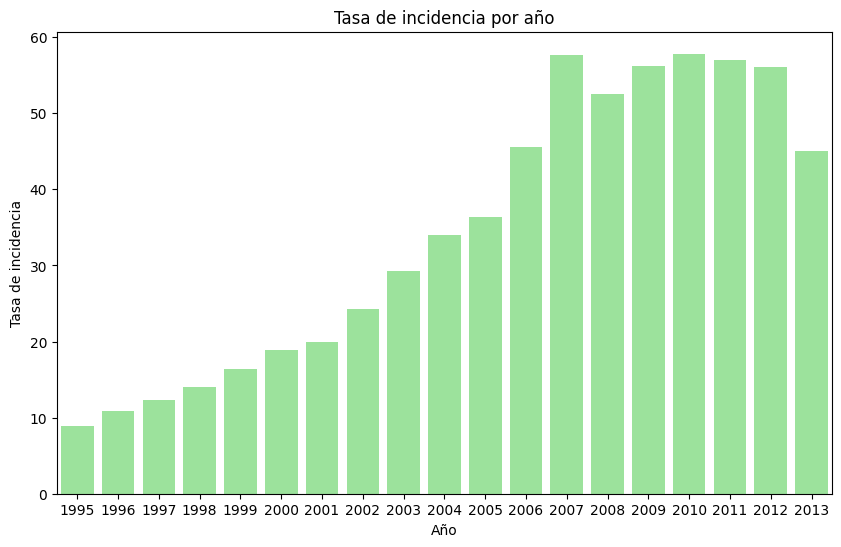

In [33]:
# Crear nuestra primera visualizacion con seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x="year", y="tasa_incidencia", data=by_year, color='lightgreen')
plt.title("Tasa de incidencia por año")
plt.xlabel("Año")
plt.ylabel("Tasa de incidencia")
# guardar la grafica en nuestro drive
plt.savefig("/content/drive/MyDrive/A/grafica_incidencia.png")

In [34]:
# grafica de barras con plotly
fig = px.bar(by_year, x="year", y="tasa_incidencia")
fig.show()